# Market exploration

The aim of this notebook is to essentially compare how different financial assets have performed since 1990 and begin exploring their change in behaviour over time.

Within the notebook the first step will be looking at raw prices, then normalise each asset to a common starting value so that their relative performance can be compared more fairly later on.

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
benchmarks = [
    "SPY", # S&P 500
    "QQQ", # Nasdaq 100
    "IWM", # US Small Caps
    "TLT", # Long-term US Treasuries
    "GLD", # Gold
]

In [9]:
companies = [
    # Techn Companies
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL",
    "CRM", "CSCO", "IBM", "AMD", "QCOM",
    "TXN", "INTU", "NOW",

    # Communication / consumer technology
    "GOOGL", "META", "NFLX", "DIS",

    # Consumer (what people buy)
    "AMZN", "TSLA", "WMT", "COST", "HD",
    "MCD", "NKE", "BKNG",

    # Financials 
    "JPM", "BAC", "GS", "MS", "AXP",
    "V", "MA", "BRK-B",

    # Healthcare 
    "LLY", "JNJ", "ABBV", "UNH", "TMO",
    "ABT", "AMGN",

    # Energy 
    "XOM", "CVX",

    # Industrials
    "GE", "CAT", "RTX",

    # Consumer staples (Everyday essentials)
    "PG", "KO", "PEP", "PM",

    # Materials
    "LIN"
]

In [10]:
tickers = benchmarks + companies

In [19]:
# As mentioned in the markdown I started the research from 1980.

prices = yf.download(
    tickers, 
    start="1980-01-01",
    auto_adjust=True,
    progress=False,
)["Close"]

prices.head()

Ticker,AAPL,ABBV,ABT,AMD,AMGN,AMZN,AVGO,AXP,BAC,BKNG,...,RTX,SPY,TLT,TMO,TSLA,TXN,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.727112,0.541403,NaN,...,0.502631,NaN,NaN,NaN,NaN,0.781620,NaN,NaN,0.024395,0.470878
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.727112,0.536390,NaN,...,0.507091,NaN,NaN,NaN,NaN,0.785110,NaN,NaN,0.024122,0.458860
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.739282,0.536390,NaN,...,0.551704,NaN,NaN,NaN,NaN,0.789762,NaN,NaN,0.024668,0.463230
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.754493,0.541403,NaN,...,0.579958,NaN,NaN,NaN,NaN,0.799067,NaN,NaN,0.024577,0.461045
1980-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.778832,0.536390,NaN,...,0.587393,NaN,NaN,NaN,NaN,0.888628,NaN,NaN,0.025032,0.464323


In [20]:
for ticker in prices.columns:
    first_date = prices[ticker].first_valid_index()

    if first_date is not None and first_date.year < 1990:
        print(ticker, first_date.date())

AAPL 1980-12-12
ABT 1980-03-17
AMD 1980-03-17
AMGN 1983-06-17
AXP 1980-01-02
BAC 1980-01-02
CAT 1980-01-02
COST 1986-07-09
CVX 1980-01-02
DIS 1980-01-02
GE 1980-01-02
HD 1981-09-22
IBM 1980-01-02
JNJ 1980-01-02
JPM 1980-03-17
KO 1980-01-02
LLY 1980-01-02
MCD 1980-01-02
MSFT 1986-03-13
NKE 1980-12-02
ORCL 1986-03-12
PEP 1980-01-02
PG 1980-01-02
RTX 1980-01-02
TMO 1980-03-17
TXN 1980-01-02
UNH 1984-10-17
WMT 1980-01-02
XOM 1980-01-02


##### It is interesting to look at datasets from decades ago. There are companies such as Amazon, Nvidia, Google, Metga and Tesla that enter much later. Which gives a more interesting breath of changes in financal characteristics and market regimes rather than forcing everything to have the same start date.

In [23]:
first_dates = prices.apply(lambda x: x.first_valid_index())

first_dates = (
    first_dates
    .sort_values()
    .rename("First Available Date")
    .to_frame()
)

first_dates

,First Available Date
Ticker,
KO,1980-01-02
TXN,1980-01-02
RTX,1980-01-02
PG,1980-01-02
PEP,1980-01-02
MCD,1980-01-02
LLY,1980-01-02
WMT,1980-01-02
JNJ,1980-01-02


## Daily returns:

Raw prices are useful in the understanding of the value of an asset, but the performance of investments normally analysed using returns. 

A daily return measures the percange change in price from one trading day to the next.

A clear example can be, if a share rises from £100 to £103, the daily return of the share is 3%





In [24]:
daily_returns = prices.pct_change(fill_method=None)

daily_returns.head()

Ticker,AAPL,ABBV,ABT,AMD,AMGN,AMZN,AVGO,AXP,BAC,BKNG,...,RTX,SPY,TLT,TMO,TSLA,TXN,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-0.009260,NaN,...,0.008874,NaN,NaN,NaN,NaN,0.004464,NaN,NaN,-0.011188,-0.025523
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016737,0.000000,NaN,...,0.087977,NaN,NaN,NaN,NaN,0.005926,NaN,NaN,0.022628,0.009525
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020575,0.009346,NaN,...,0.051213,NaN,NaN,NaN,NaN,0.011782,NaN,NaN,-0.003695,-0.004718
1980-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032259,-0.009260,NaN,...,0.012821,NaN,NaN,NaN,NaN,0.112081,NaN,NaN,0.018522,0.007110


### Sanity check: manual return calculation

Simply to verify the daily return calculations, I manually calculated Apple's first available daily return and compare it with the results from 'pct_change()'

In [28]:
first_two = prices["AAPL"].dropna().iloc[:2]

manual_return = first_two.iloc[1] / first_two.iloc[0] - 1
calculated_return = daily_returns["AAPL"].dropna().iloc[0]

print(f"Manual return: {manual_return:.4%}")
print(f"pct_change return: {calculated_return:.4%}")

Manual return: -5.2171%
pct_change return: -5.2171%


In [30]:
assert np.isclose(manual_return, calculated_return)

## Long-term Performance Summary

Total returns show the hoc much an asset has grown over its full available history (in this case backed from 1980).

Because there are so many different companies that have been entered in the dataset in different dates, I have also decided to calcualte CAGR, the compound annual growth rate, which expresses the annual growth over the period of time.

In [31]:
summary = []

for ticker in prices.columns:
    series = prices[ticker].dropna()

    if len(series) < 2:
        continue

    first_date = series.index[0]
    last_date = series.index[-1]

    first_price = series.iloc[0]
    last_price = series.iloc[-1]

    years = (last_date - first_date).days / 365.25

    total_return = last_price / first_price - 1

    cagr = (last_price / first_price) ** (1 / years) - 1

    summary.append({
        "Ticker": ticker,
        "First Date": first_date,
        "Years": years,
        "Total Return %": total_return * 100,
        "CAGR %": cagr * 100
    })

performance_summary = pd.DataFrame(summary)

In [32]:
performance_summary.sort_values(
    "CAGR %",
    ascending=False
).head(15)

,Ticker,First Date,Years,Total Return %,CAGR %
6,AVGO,2009-08-06,17.092402,3.198724e+04,40.163293
49,TSLA,2010-06-29,16.197125,2.299397e+04,39.933232
38,NVDA,1999-01-22,27.630390,5.954152e+05,36.968609
5,AMZN,1997-05-15,29.319644,2.576693e+05,30.721274
35,NFLX,2002-05-23,24.298426,6.344738e+04,30.425133
30,MA,2006-05-25,20.292950,1.354264e+04,27.410127
37,NOW,2012-06-29,14.195756,2.564837e+03,26.017065
34,MSFT,1986-03-13,40.492813,8.330037e+05,24.975409
19,GOOGL,2004-08-19,22.056126,1.319330e+04,24.819700
21,HD,1981-09-22,44.963723,1.894336e+06,24.489235


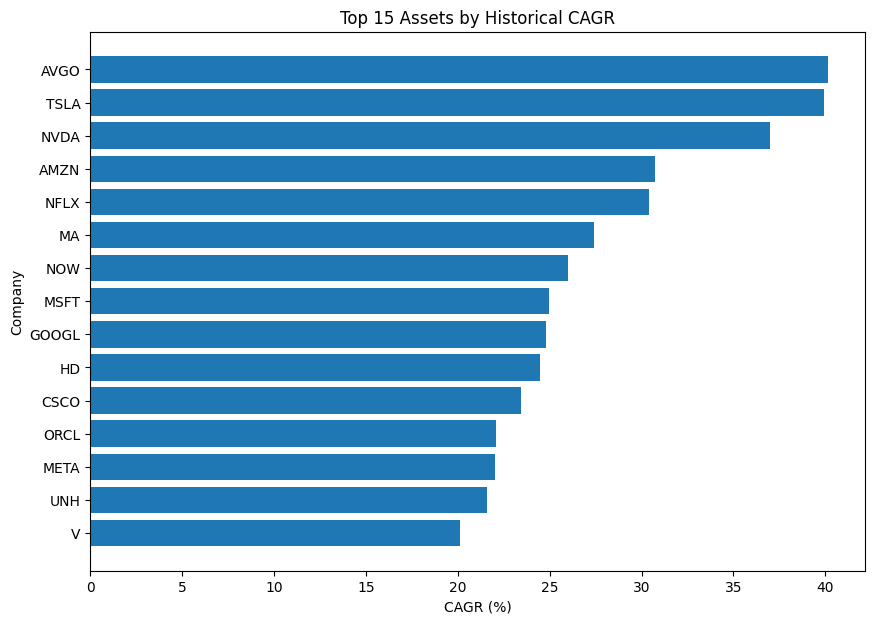

In [33]:
top_15 = (
    performance_summary
    .sort_values("CAGR %", ascending=False)
    .head(15)
    .sort_values("CAGR %")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15["Ticker"],
    top_15["CAGR %"]
)

plt.xlabel("CAGR (%)")
plt.ylabel("Company")
plt.title("Top 15 Assets by Historical CAGR")

plt.show()

### Initial observations

The highest hiostorical CAGRs are dominated by the technology and growth companies.

Although, however the companioes have all different starting dates. So CAGR does not make them perfectly comparable. This is simply because newer companies may have experience very different market conditions from firms with several decaes of history. 

Microsoft stands out because it has masintained a high CAGR over a relatively long period, while UnitedHealth (UNH) is notable as one of the few non-technology companies near the top of the rankings. 

In [34]:
annualised_volatility = daily_returns.std() * np.sqrt(252)

volatility_table = (
    annualised_volatility
    .sort_values(ascending=False)
    .mul(100)
    .rename("Annualised Volatility %")
    .to_frame()
)

volatility_table.head(15)

,Annualised Volatility %
Ticker,
BKNG,59.609767
AMD,59.349518
NVDA,59.195397
TSLA,57.371912
AMZN,54.965237
NFLX,54.309013
QCOM,48.448348
ORCL,46.739590
INTU,45.684765


In [35]:
analysis_table = performance_summary.merge(
    volatility_table,
    left_on="Ticker",
    right_index=True
)

analysis_table.sort_values(
    "Annualised Volatility %",
    ascending=False
).head(15)

,Ticker,First Date,Years,Total Return %,CAGR %,Annualised Volatility %
9,BKNG,1999-03-31,27.444216,790.467742,8.293343,59.609767
3,AMD,1980-03-17,46.480493,16464.610014,11.620601,59.349518
38,NVDA,1999-01-22,27.630390,595415.159527,36.968609,59.195397
49,TSLA,2010-06-29,16.197125,22993.967624,39.933232,57.371912
5,AMZN,1997-05-15,29.319644,257669.334366,30.721274,54.965237
35,NFLX,2002-05-23,24.298426,63447.384329,30.425133,54.309013
43,QCOM,1991-12-13,34.740589,52469.399538,19.761075,48.448348
39,ORCL,1986-03-12,40.495551,321631.073335,22.071500,46.739590
23,INTU,1993-03-12,33.494867,13469.570834,15.789305,45.684765
33,MS,1993-02-23,33.541410,6218.674010,13.157585,44.978275


### Total return observation

The highest total returns are concentrated in companies such as NVIDIA, Amazon, Oracle, Apple and UnitedHealth.

This clearly reflects both a strong historical growth and the effect of compouding over long periods. Therefore the total return is in favour of companies with a more long term sucessful trading history, while CAGR is more sueful for comparing growth rates across different time spans > 1.

In [36]:
risk_free = yf.download(
    "^IRX",
    start="1980-01-01",
    auto_adjust=False,
    progress=False
)["Close"]

In [37]:
risk_free = risk_free.squeeze()
risk_free.name = "Risk Free Yield %"

In [38]:
daily_rf = (1 + risk_free / 100) ** (1 / 252) - 1

In [39]:
daily_rf = (
    daily_rf
    .reindex(daily_returns.index)
    .ffill()
)

In [40]:
excess_returns = daily_returns.sub(daily_rf, axis=0)

In [43]:
sharpe_results = {}

for ticker in daily_returns.columns:

    combined = pd.concat(
        [
            daily_returns[ticker].rename("Asset Return"),
            daily_rf.rename("Risk Free Return")
        ],
        axis=1
    ).dropna()

    excess = (
        combined["Asset Return"]
        - combined["Risk Free Return"]
    )

    sharpe = (
        excess.mean()
        / combined["Asset Return"].std()
    ) * np.sqrt(252)

    sharpe_results[ticker] = sharpe

sharpe_table = (
    pd.Series(sharpe_results)
    .sort_values(ascending=False)
    .rename("Sharpe Ratio")
    .to_frame()
)

sharpe_table.head(10)

,Sharpe Ratio
AVGO,1.039513
MA,0.863831
TSLA,0.846664
GOOGL,0.819406
NVDA,0.793272
ABBV,0.764280
MSFT,0.747100
V,0.742318
NFLX,0.733447
NOW,0.721540


In [44]:
risk_return = performance_summary[
    ["Ticker", "CAGR %"]
].merge(
    volatility_table,
    left_on="Ticker",
    right_index=True
).dropna()

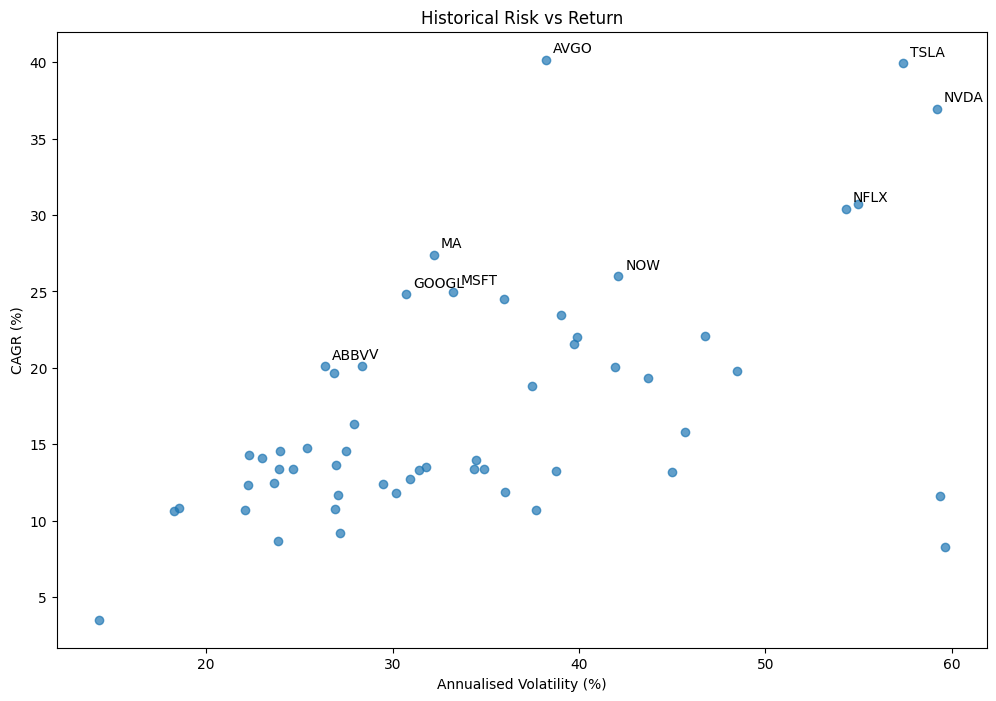

In [48]:
plt.figure(figsize=(12, 8))

plt.scatter(
    risk_return["Annualised Volatility %"],
    risk_return["CAGR %"],
    alpha=0.7
)

plt.xlabel("Annualised Volatility (%)")
plt.ylabel("CAGR (%)")
plt.title("Historical Risk vs Return")

for ticker in sharpe_table.head(10).index:
    row = risk_return[
        risk_return["Ticker"] == ticker
    ]

    if not row.empty:
        plt.annotate(
            ticker,
            (
                row["Annualised Volatility %"].iloc[0],
                row["CAGR %"].iloc[0]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.show()

In [49]:
max_drawdowns = {}

for ticker in prices.columns:
    series = prices[ticker].dropna()

    running_peak = series.cummax()

    drawdown = series / running_peak - 1

    max_drawdowns[ticker] = drawdown.min()

In [50]:
drawdown_table = (
    pd.Series(max_drawdowns)
    .mul(100)
    .sort_values()
    .rename("Maximum Drawdown %")
    .to_frame()
)

drawdown_table.head(15)

,Maximum Drawdown %
BKNG,-99.322556
AMD,-96.589474
AMZN,-94.404218
BAC,-93.445713
NVDA,-89.722433
CSCO,-89.258394
MS,-88.117901
QCOM,-86.754971
TXN,-85.812351
GE,-85.529085


In [51]:
def plot_drawdown(ticker):
    series = prices[ticker].dropna()
    running_peak = series.cummax()
    drawdown = (series / running_peak - 1) * 100

    plt.figure(figsize=(12, 5))
    plt.plot(drawdown.index, drawdown)

    plt.axhline(0, linewidth=1)

    plt.title(f"{ticker} Historical Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")

    plt.show()

    print("Worst drawdown:", drawdown.min())
    print("Date of worst drawdown:", drawdown.idxmin())
    

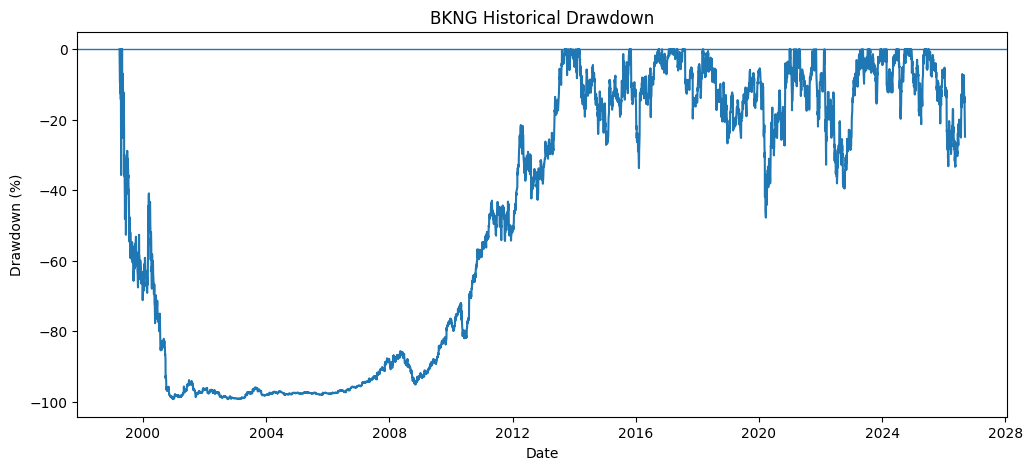

Worst drawdown: -99.32255597186138
Date of worst drawdown: 2002-10-09 00:00:00


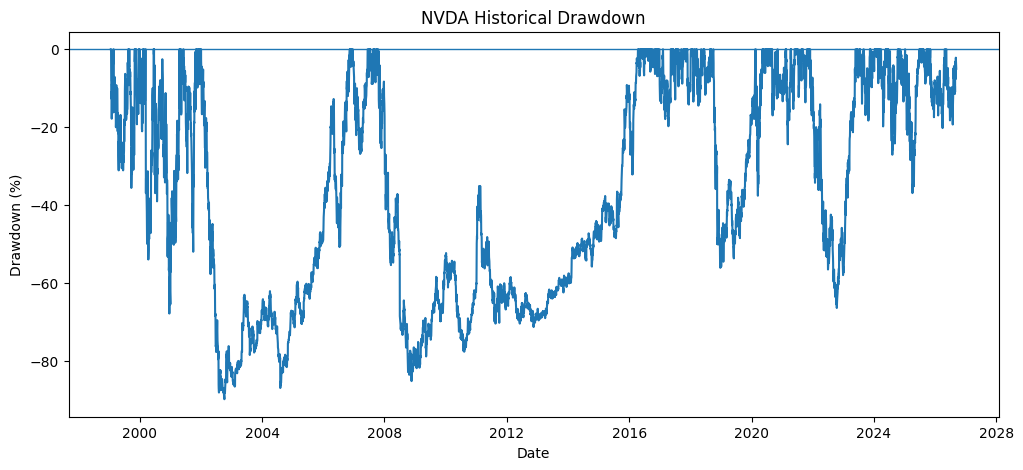

Worst drawdown: -89.72243323063329
Date of worst drawdown: 2002-10-09 00:00:00


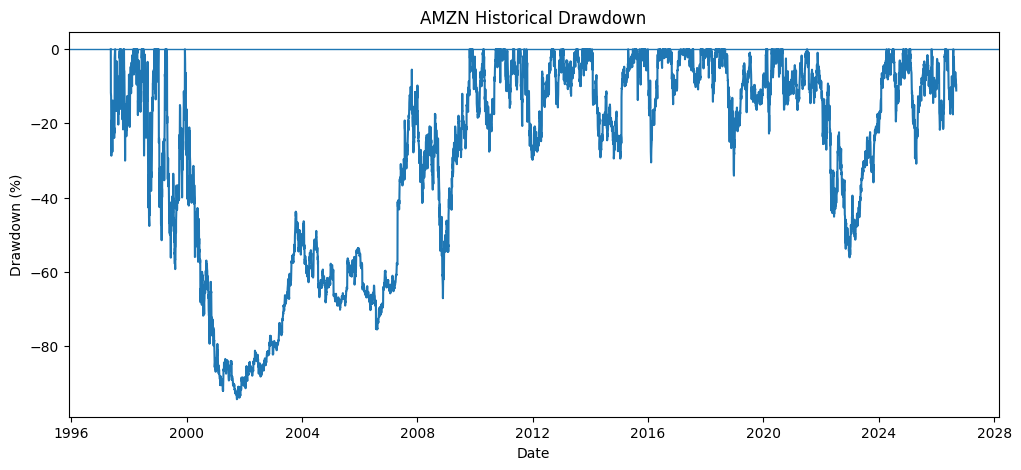

Worst drawdown: -94.40421779932859
Date of worst drawdown: 2001-09-28 00:00:00


In [52]:
plot_drawdown("BKNG")
plot_drawdown("NVDA")
plot_drawdown("AMZN")

The interesting part of this is that large long-term returns can hide actual severe historical losses. 

Therefore maximum drawdown provides information about downside experience that both CAGR and volatility alone do not capture.

In [54]:
correlation_matrix = daily_returns.corr()

correlation_matrix.head()


Ticker,AAPL,ABBV,ABT,AMD,AMGN,AMZN,AVGO,AXP,BAC,BKNG,...,RTX,SPY,TLT,TMO,TSLA,TXN,UNH,V,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.245704,0.222128,0.335668,0.249637,0.324669,0.464074,0.315519,0.253452,0.286993,...,0.277329,0.487093,-0.177066,0.257283,0.361924,0.383233,0.184915,0.487850,0.261148,0.229599
ABBV,0.245704,1.000000,0.414405,0.130673,0.484991,0.180876,0.194870,0.293609,0.293665,0.236068,...,0.305203,0.423954,-0.102423,0.380608,0.135567,0.259652,0.321107,0.356059,0.226543,0.272322
ABT,0.222128,0.414405,1.000000,0.198339,0.314870,0.157611,0.254735,0.340693,0.281262,0.158008,...,0.325400,0.479230,-0.153862,0.306950,0.174997,0.237109,0.261775,0.425548,0.331809,0.299794
AMD,0.335668,0.130673,0.198339,1.000000,0.172065,0.292493,0.419748,0.310095,0.262359,0.249766,...,0.256521,0.475891,-0.159948,0.261943,0.323006,0.475233,0.145198,0.338144,0.191349,0.210541
AMGN,0.249637,0.484991,0.314870,0.172065,1.000000,0.268455,0.255339,0.273003,0.226196,0.195044,...,0.242466,0.457335,-0.144761,0.262299,0.161296,0.255904,0.239823,0.358492,0.259477,0.217615


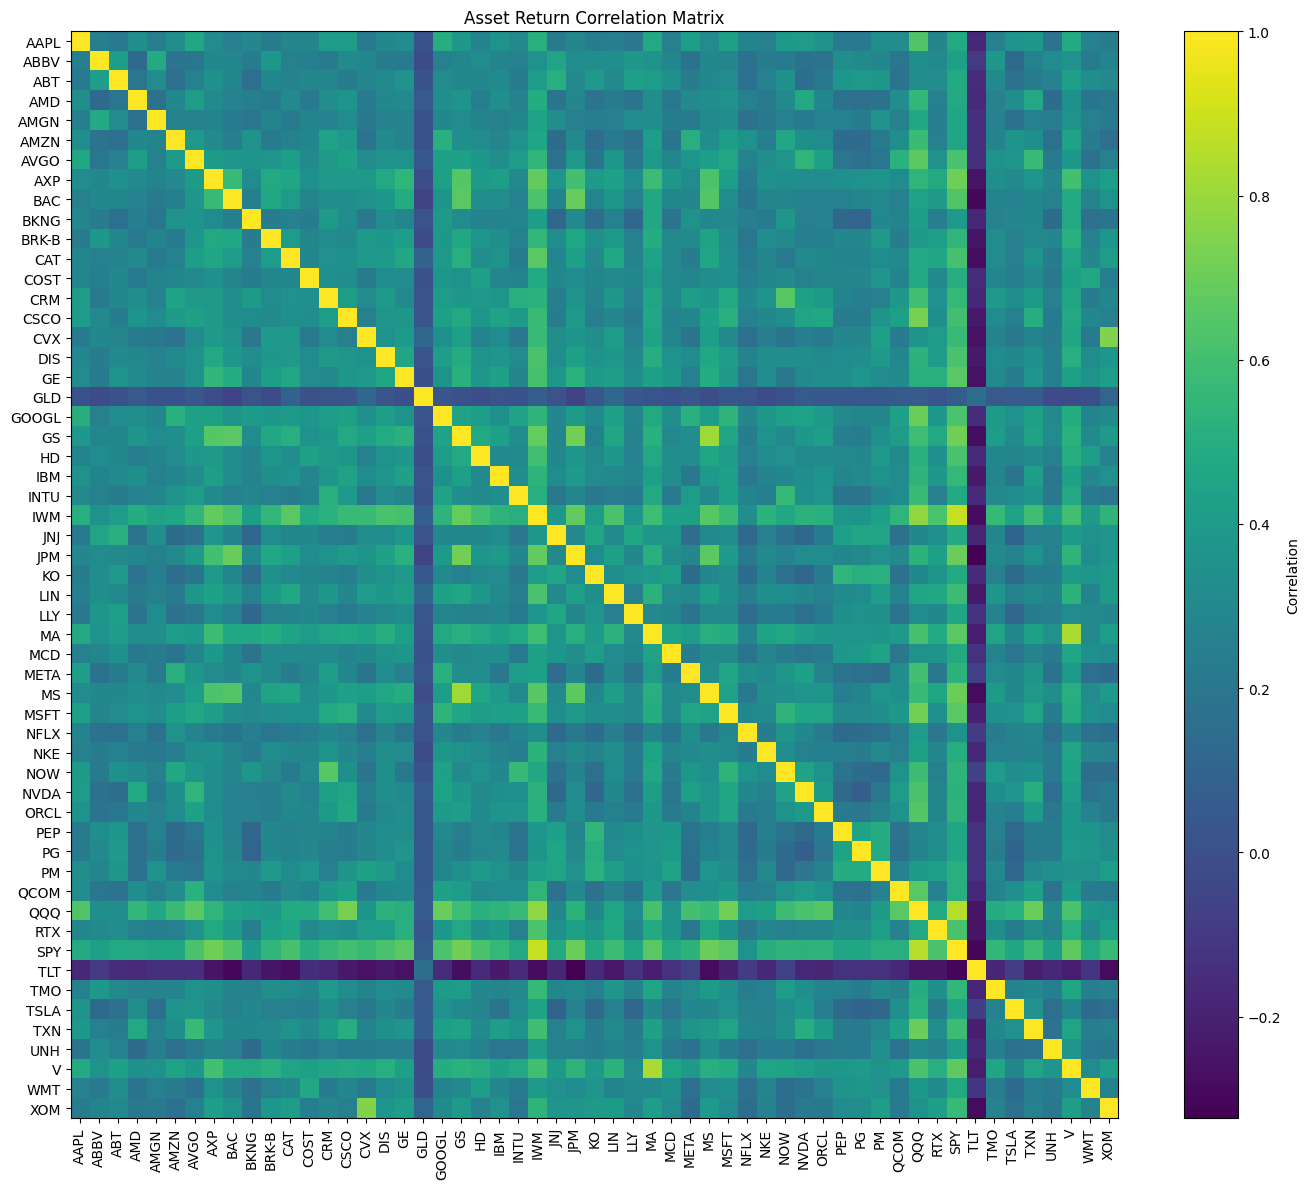

In [55]:
plt.figure(figsize=(14, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Asset Return Correlation Matrix")

plt.tight_layout()
plt.show()

In [64]:
spy_correlations = (
    correlation_matrix["SPY"]
    .drop("SPY")
    .sort_values(ascending=False)
    .rename("Correlation with SPY")
    .to_frame()
)

spy_correlations.head(10)

,Correlation with SPY
Ticker,
IWM,0.886215
QQQ,0.852649
GS,0.710826
AXP,0.706273
MS,0.704554
JPM,0.697094
V,0.671196
GE,0.661971
MA,0.659593


In [65]:
spy_correlations.tail(10)

,Correlation with SPY
Ticker,
AMGN,0.457335
AMZN,0.456840
TSLA,0.456060
PEP,0.452531
ABBV,0.423954
UNH,0.417017
BKNG,0.393146
NFLX,0.350148
GLD,0.066014


In [66]:
correlation_matrix.loc[
    ["SPY", "QQQ", "IWM", "TLT", "GLD"],
    ["SPY", "QQQ", "IWM", "TLT", "GLD"]
]

Ticker,SPY,QQQ,IWM,TLT,GLD
Ticker,,,,,
SPY,1.000000,0.852649,0.886215,-0.301170,0.066014
QQQ,0.852649,1.000000,0.780772,-0.254292,0.057602
IWM,0.886215,0.780772,1.000000,-0.280877,0.070016
TLT,-0.301170,-0.254292,-0.280877,1.000000,0.156324
GLD,0.066014,0.057602,0.070016,0.156324,1.000000


In [67]:
betas = {}

for ticker in daily_returns.columns:

    if ticker == "SPY":
        continue

    combined = pd.concat(
        [
            daily_returns[ticker].rename("Asset"),
            daily_returns["SPY"].rename("Market")
        ],
        axis=1
    ).dropna()

    covariance = combined["Asset"].cov(combined["Market"])
    market_variance = combined["Market"].var()

    beta = covariance / market_variance

    betas[ticker] = beta

In [68]:
beta_table = (
    pd.Series(betas)
    .sort_values(ascending=False)
    .rename("Beta vs SPY")
    .to_frame()
)

beta_table.head(10)

,Beta vs SPY
MS,1.708356
NVDA,1.636393
AMD,1.575088
TSLA,1.542866
BAC,1.395985
AVGO,1.386895
NOW,1.354310
JPM,1.345238
GS,1.333704
AXP,1.315603


In [69]:
beta_table.tail(10)

,Beta vs SPY
ABT,0.648122
BRK-B,0.627463
PM,0.608735
MCD,0.600692
KO,0.561675
PEP,0.545315
PG,0.538308
JNJ,0.537871
GLD,0.063908
TLT,-0.228775


In [70]:
portfolio_weights = {
    "SPY": 0.35,
    "QQQ": 0.15,
    "IWM": 0.10,
    "TLT": 0.15,
    "GLD": 0.10,
    "JPM": 0.05,
    "JNJ": 0.05,
    "XOM": 0.05
}

In [71]:
portfolio_returns = daily_returns[
    list(portfolio_weights.keys())
].dropna()

In [72]:
weights = pd.Series(portfolio_weights)

In [73]:
portfolio_daily_returns = (
    portfolio_returns * weights
).sum(axis=1)

In [74]:
portfolio_annual_return = (
    portfolio_daily_returns.mean() * 252
)

In [75]:
portfolio_annual_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

In [76]:
print(
    f"Annualised Return: "
    f"{portfolio_annual_return:.2%}"
)

print(
    f"Annualised Volatility: "
    f"{portfolio_annual_volatility:.2%}"
)

Annualised Return: 11.76%
Annualised Volatility: 14.17%


In [77]:
spy_same_period = portfolio_returns["SPY"]

spy_annual_return = spy_same_period.mean() * 252
spy_annual_volatility = spy_same_period.std() * np.sqrt(252)

print(f"Portfolio Return: {portfolio_annual_return:.2%}")
print(f"Portfolio Volatility: {portfolio_annual_volatility:.2%}")

print(f"SPY Return: {spy_annual_return:.2%}")
print(f"SPY Volatility: {spy_annual_volatility:.2%}")

Portfolio Return: 11.76%
Portfolio Volatility: 14.17%
SPY Return: 12.16%
SPY Volatility: 18.86%


In [78]:
portfolio_growth = (1 + portfolio_daily_returns).cumprod()

portfolio_peak = portfolio_growth.cummax()

portfolio_drawdown = portfolio_growth / portfolio_peak - 1

portfolio_max_drawdown = portfolio_drawdown.min()

print(f"Portfolio Maximum Drawdown: {portfolio_max_drawdown:.2%}")

Portfolio Maximum Drawdown: -36.80%


In [79]:
spy_growth = (1 + spy_same_period).cumprod()

spy_peak = spy_growth.cummax()

spy_drawdown = spy_growth / spy_peak - 1

spy_max_drawdown = spy_drawdown.min()

print(f"SPY Maximum Drawdown: {spy_max_drawdown:.2%}")

SPY Maximum Drawdown: -55.19%


In [80]:
portfolio_rf = daily_rf.reindex(
    portfolio_daily_returns.index
).ffill()

portfolio_excess = (
    portfolio_daily_returns - portfolio_rf
).dropna()

portfolio_sharpe = (
    portfolio_excess.mean()
    / portfolio_daily_returns.loc[portfolio_excess.index].std()
) * np.sqrt(252)

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")

Portfolio Sharpe Ratio: 0.71


In [81]:
spy_rf = daily_rf.reindex(
    spy_same_period.index
).ffill()

spy_excess = (
    spy_same_period - spy_rf
).dropna()

spy_sharpe = (
    spy_excess.mean()
    / spy_same_period.loc[spy_excess.index].std()
) * np.sqrt(252)

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")
print(f"SPY Sharpe Ratio: {spy_sharpe:.2f}")

Portfolio Sharpe Ratio: 0.71
SPY Sharpe Ratio: 0.55


### Diversification observation

The diverisifcation within the portfolio produced is a slightlky lower annualised return than SPY, but with substantially lower volatility and a smaller maximum drawdown.

This suggets that combing assets with different return charactersitics, including bonds and gold, improved the historical profile of the portfolio without a large reduction in return. 

In [83]:
cov_matrix = portfolio_returns.cov() * 252

weights = pd.Series(
    portfolio_weights
).reindex(portfolio_returns.columns)

portfolio_vol = np.sqrt(
    weights.T @ cov_matrix @ weights
)

In [84]:
marginal_risk = (
    cov_matrix @ weights
) / portfolio_vol

In [85]:
component_risk = weights * marginal_risk

risk_contribution = (
    component_risk / portfolio_vol
) * 100

In [86]:
risk_contribution_table = pd.DataFrame({
    "Weight %": weights * 100,
    "Risk Contribution %": risk_contribution
})

risk_contribution_table.sort_values(
    "Risk Contribution %",
    ascending=False
)

,Weight %,Risk Contribution %
Ticker,,
SPY,35.0,45.220050
QQQ,15.0,20.694130
IWM,10.0,15.317344
JPM,5.0,8.941438
XOM,5.0,5.972381
JNJ,5.0,3.340576
GLD,10.0,2.748433
TLT,15.0,-2.234352


### Risk contribution observation

The weight (%) of a portfolio does not necessary correspond to portfolio risk. 

Although SPY, QQ and IWM account for about 60%of the total portfolio's capiotal, they also contribute to roughly 81% of the total portfolio volatility. 

WQWhereas TLT has a weight of 15% of the portfoliop but has a negative historical risk contribution, clearly indicating that tits relationship with the other holdings reduced overall portfolio volatility during the sample period.

In [87]:
stress_periods = {
    "Global Financial Crisis": ("2007-10-01", "2009-03-31"),
    "COVID Crash": ("2020-02-01", "2020-04-30"),
    "2022 Selloff": ("2022-01-01", "2022-12-31")
}

In [88]:
def stress_test(start, end):
    p = portfolio_daily_returns.loc[start:end]
    s = spy_same_period.loc[start:end]

    portfolio_growth = (1 + p).cumprod()
    spy_growth = (1 + s).cumprod()

    portfolio_return = portfolio_growth.iloc[-1] - 1
    spy_return = spy_growth.iloc[-1] - 1

    portfolio_dd = (
        portfolio_growth / portfolio_growth.cummax() - 1
    ).min()

    spy_dd = (
        spy_growth / spy_growth.cummax() - 1
    ).min()

    return {
        "Portfolio Return %": portfolio_return * 100,
        "SPY Return %": spy_return * 100,
        "Portfolio Max Drawdown %": portfolio_dd * 100,
        "SPY Max Drawdown %": spy_dd * 100
    }

In [89]:
stress_results = {}

for name, (start, end) in stress_periods.items():
    stress_results[name] = stress_test(start, end)

stress_table = pd.DataFrame(stress_results).T
stress_table

,Portfolio Return %,SPY Return %,Portfolio Max Drawdown %,SPY Max Drawdown %
Global Financial Crisis,-24.899861,-45.961340,-36.800398,-55.189450
COVID Crash,-3.731748,-9.182192,-25.256745,-33.717274
2022 Selloff,-15.392543,-18.175356,-21.397835,-24.496406


In [90]:
portfolio_assets = list(portfolio_weights.keys())

asset_stress_results = {}

for period_name, (start, end) in stress_periods.items():

    period_returns = portfolio_returns[
        portfolio_assets
    ].loc[start:end]

    cumulative_returns = (
        (1 + period_returns).prod() - 1
    ) * 100

    asset_stress_results[period_name] = cumulative_returns

asset_stress_table = pd.DataFrame(asset_stress_results)

asset_stress_table

,Global Financial Crisis,COVID Crash,2022 Selloff
Ticker,,,
SPY,-45.961340,-9.182192,-18.175356
QQQ,-40.650595,0.139890,-32.577007
IWM,-46.312449,-18.511241,-20.484809
TLT,27.163487,14.808262,-31.234543
GLD,22.813217,6.341660,-0.772115
JPM,-38.655268,-26.900044,-12.641197
JNJ,-16.434518,1.428640,5.974887
XOM,-24.299137,-24.119197,87.409112


In [92]:
common_start = "2012-01-01"

common_prices = prices.loc[common_start:].copy()

common_returns = common_prices.pct_change(
    fill_method=None
)

In [93]:
eligible_tickers = []

for ticker in common_prices.columns:
    first_valid = common_prices[ticker].first_valid_index()

    if first_valid is not None and first_valid <= pd.Timestamp("2012-02-01"):
        eligible_tickers.append(ticker)

len(eligible_tickers)

52

In [94]:
company_start_dates = {
    ticker: prices[ticker].first_valid_index()
    for ticker in companies
}

latest_starts = (
    pd.Series(company_start_dates)
    .sort_values(ascending=False)
)

latest_starts.head(10)

ABBV    2013-01-02
NOW     2012-06-29
META    2012-05-18
TSLA    2010-06-29
AVGO    2009-08-06
V       2008-03-19
PM      2008-03-17
MA      2006-05-25
GOOGL   2004-08-19
CRM     2004-06-23
dtype: datetime64[ns]

In [95]:
common_start = latest_starts.max()

print("Common start date:", common_start)

Common start date: 2013-01-02 00:00:00


In [96]:
common_prices = prices[companies].loc[common_start:].copy()

common_returns = common_prices.pct_change(
    fill_method=None
)

In [97]:
common_prices.head()

Ticker,AAPL,MSFT,NVDA,AVGO,ORCL,CRM,CSCO,IBM,AMD,QCOM,...,XOM,CVX,GE,CAT,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,16.567114,22.102659,0.293077,2.359187,28.564457,42.064758,13.543345,111.584160,2.53,44.784790,...,51.359951,62.607422,81.509636,66.921371,38.573753,46.935905,24.749620,45.721149,45.290222,87.612076
2013-01-03,16.357998,21.806568,0.293307,2.371512,28.251556,41.460220,13.616595,110.970428,2.49,44.577293,...,51.267300,62.340855,80.592949,67.565498,38.716091,46.638279,24.749620,45.740936,44.830742,87.612076
2013-01-04,15.902351,21.398445,0.302984,2.356286,28.498590,41.681396,13.636565,110.242989,2.59,43.920235,...,51.504669,62.669815,80.974915,67.937683,39.023769,46.732952,24.789114,45.806873,45.175343,88.203506
2013-01-07,15.808812,21.358433,0.294229,2.343236,28.350368,41.526573,13.510059,109.759995,2.67,44.272957,...,50.908352,62.244457,80.707520,68.145256,38.835491,46.415047,24.552153,45.800278,45.034382,88.008957
2013-01-08,15.851352,21.246393,0.287778,2.327285,28.358599,41.769863,13.523375,109.606483,2.67,44.203800,...,51.226791,61.966545,79.829018,67.279221,38.367107,46.340652,24.381020,45.938778,44.950840,88.623764


In [98]:
common_summary = []

for ticker in common_prices.columns:

    series = common_prices[ticker].dropna()

    first_price = series.iloc[0]
    last_price = series.iloc[-1]

    first_date = series.index[0]
    last_date = series.index[-1]

    years = (last_date - first_date).days / 365.25

    cagr = (
        (last_price / first_price) ** (1 / years)
        - 1
    )

    common_summary.append({
        "Ticker": ticker,
        "CAGR %": cagr * 100
    })

common_performance = pd.DataFrame(common_summary)

In [99]:
common_performance.sort_values(
    "CAGR %",
    ascending=False
).head(10)

,Ticker,CAGR %
2,NVDA,62.427706
8,AMD,47.601395
18,TSLA,44.636386
3,AVGO,44.529084
15,NFLX,34.519027
33,LLY,28.158054
14,META,25.969529
1,MSFT,25.444950
12,NOW,25.221130
17,AMZN,24.298759


In [100]:
common_volatility = (
    common_returns.std()
    * np.sqrt(252)
    * 100
)

common_volatility = (
    common_volatility
    .rename("Volatility %")
    .to_frame()
)

In [101]:
common_rf = (
    daily_rf
    .reindex(common_returns.index)
    .ffill()
)

In [102]:
common_sharpes = {}

for ticker in common_returns.columns:

    combined = pd.concat(
        [
            common_returns[ticker].rename("Asset Return"),
            common_rf.rename("Risk Free Return")
        ],
        axis=1
    ).dropna()

    excess = (
        combined["Asset Return"]
        - combined["Risk Free Return"]
    )

    sharpe = (
        excess.mean()
        / combined["Asset Return"].std()
    ) * np.sqrt(252)

    common_sharpes[ticker] = sharpe

In [103]:
common_sharpe_table = (
    pd.Series(common_sharpes)
    .rename("Sharpe Ratio")
    .to_frame()
)

In [104]:
common_analysis = (
    common_performance
    .merge(
        common_volatility,
        left_on="Ticker",
        right_index=True
    )
    .merge(
        common_sharpe_table,
        left_on="Ticker",
        right_index=True
    )
)

In [105]:
common_analysis.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(15)

,Ticker,CAGR %,Volatility %,Sharpe Ratio
2,NVDA,62.427706,45.407345,1.258268
3,AVGO,44.529084,38.371561,1.108608
33,LLY,28.158054,28.304775,0.958032
8,AMD,47.601395,57.957016,0.927786
1,MSFT,25.444950,26.854502,0.915766
18,TSLA,44.636386,57.450040,0.899253
20,COST,19.413156,20.619838,0.881823
15,NFLX,34.519027,44.594851,0.849179
0,AAPL,24.024427,28.252961,0.843972
13,GOOGL,23.738560,28.109213,0.837925
